# Early COVID-19 Data Analysis

### A historical analytical snapshot from the first months of the pandemic

**NYU Stern Data Bootcamp · Spring 2020**  
**Analysis period:** primarily through May 12–13, 2020

---

This notebook is a restored and polished version of a three-person final project originally developed during the first wave of COVID-19 in New York City.

The restoration preserves the original analytical questions, historical data period, and collaborative work while improving presentation, reproducibility, code clarity, and interpretation.

## Project questions

Using Python and publicly available COVID-19 and financial data, the project explored four main questions:

1. Which countries were reporting the highest COVID-19 case counts?
2. How was the pandemic developing across the United States and New York City?
3. Which state-level factors were associated with differences in COVID-19 testing?
4. How did selected financial markets and companies behave during the early months of the pandemic?

Because the analysis was conducted while the pandemic was still unfolding, the results should be interpreted as a historical snapshot rather than a retrospective assessment using later knowledge.

## Analysis roadmap

**01 · Global COVID-19 snapshot**  
Global totals, country rankings, interactive visualizations, geographic patterns, population-adjusted comparisons, and case progression.

**02 · United States**  
State-level case patterns, geographic visualization, and daily case development.

**03 · New York City**  
Daily cases, hospitalizations, deaths, and demographic patterns by age and sex.

**04 · State-level testing regression**  
Exploratory relationships between COVID-19 testing and selected state characteristics.

**05 · Financial-market analysis**  
Major US indices, selected companies, and gold prices during the early pandemic period.

**06 · Limitations & conclusion**  
Historical context, methodological limitations, and key observations.

<br/>

## 01 · Global COVID-19 Snapshot

The global analysis uses historical COVID-19 data from the Johns Hopkins
University Center for Systems Science and Engineering (JHU CSSE).

To preserve the original Spring 2020 analytical window, the restored notebook
uses locally frozen historical snapshots rather than current versions of the
datasets.

Four JHU datasets support this section:

- `time_series_covid19_confirmed_global.csv` — cumulative reported confirmed
  cases by country/region and province/state;
- `time_series_covid19_deaths_global.csv` — cumulative reported deaths;
- `time_series_covid19_recovered_global.csv` — cumulative reported recoveries;
- `cases_country.csv` — country-level snapshot containing confirmed cases,
  deaths, recoveries, active cases, geographic coordinates, and related metrics.

The time-series data extend through **May 13, 2020**, and the country-level
snapshot was updated on **May 13, 2020 at 23:32:26**.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import matplotlib.animation as animation
import matplotlib.ticker as ticker

from IPython.display import display

In [2]:
# Locate the repository whether the kernel starts in the repo root
# or inside the notebooks/ directory.
cwd = Path.cwd()

if (cwd / "data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not locate the project data directory.")

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
JHU_DATA_DIR = RAW_DATA_DIR / "jhu"

# Frozen Johns Hopkins historical snapshots
CoV_deaths = pd.read_csv(
    JHU_DATA_DIR / "time_series_covid19_deaths_global.csv"
)

CoV_confirmed = pd.read_csv(
    JHU_DATA_DIR / "time_series_covid19_confirmed_global.csv"
)

CoV_recovered = pd.read_csv(
    JHU_DATA_DIR / "time_series_covid19_recovered_global.csv"
)

CoV_country = pd.read_csv(
    JHU_DATA_DIR / "cases_country.csv"
)

In [3]:
print("Global deaths:", CoV_deaths.shape)
print("Global confirmed:", CoV_confirmed.shape)
print("Global recovered:", CoV_recovered.shape)
print("Country snapshot:", CoV_country.shape)

print()
print("Time-series through:", CoV_confirmed.columns[-1])
print("Country snapshot updated:", CoV_country["Last_Update"].iloc[0])

Global deaths: (266, 117)
Global confirmed: (266, 117)
Global recovered: (253, 117)
Country snapshot: (188, 14)

Time-series through: 5/13/20
Country snapshot updated: 2020-05-13 23:32:26


### Data preparation

Column names are standardized for consistency while preserving the structure
and historical values of the original datasets.

Missing values are retained where they represent unavailable historical
information rather than being automatically imputed.

In [4]:
# Standardize column names
for df in [CoV_deaths, CoV_confirmed, CoV_recovered, CoV_country]:
    df.columns = df.columns.str.lower()

# Use consistent geographic field names
rename_global = {
    "province/state": "state",
    "country/region": "country",
}

CoV_deaths = CoV_deaths.rename(columns=rename_global)
CoV_confirmed = CoV_confirmed.rename(columns=rename_global)
CoV_recovered = CoV_recovered.rename(columns=rename_global)

CoV_country = CoV_country.rename(
    columns={
        "country_region": "country",
        "long_": "long",
    }
)

display(CoV_country.head())

,country,last_update,lat,long,confirmed,deaths,recovered,active,incident_rate,people_tested,people_hospitalized,mortality_rate,uid,iso3
0,Australia,2020-05-13 23:32:26,-25.0000,133.0000,6979,98,6271,610,27.411949,NaN,NaN,1.404213,36,AUS
1,Austria,2020-05-13 23:32:26,47.5162,14.5501,15997,624,14304,1069,177.618138,NaN,NaN,3.900731,40,AUT
2,Canada,2020-05-13 23:32:26,60.0010,-95.0010,73563,5425,35177,32961,194.324755,NaN,NaN,7.374631,124,CAN
3,China,2020-05-13 23:32:26,30.5928,114.3055,84021,4637,79242,142,5.981520,NaN,NaN,5.518858,156,CHN
4,Denmark,2020-05-13 23:32:26,56.0000,10.0000,10865,533,8861,1471,187.579752,NaN,NaN,4.905660,208,DNK


In [5]:
assert CoV_confirmed.columns[-1] == "5/13/20"
assert CoV_country["last_update"].iloc[0] == "2020-05-13 23:32:26"

print("Historical JHU inputs loaded and standardized successfully.")

Historical JHU inputs loaded and standardized successfully.


### Global overview

Reported global totals provide a high-level view of the pandemic at the end of
the historical analysis window. The figures below reflect the JHU country-level
snapshot from May 13, 2020.

In [6]:
global_totals = {
    "Confirmed": int(CoV_country["confirmed"].sum()),
    "Deaths": int(CoV_country["deaths"].sum()),
    "Recovered": int(CoV_country["recovered"].sum()),
    "Active": int(CoV_country["active"].sum()),
}

global_totals

{'Confirmed': 4342565,
 'Deaths': 296690,
 'Recovered': 1546811,
 'Active': 2504227}

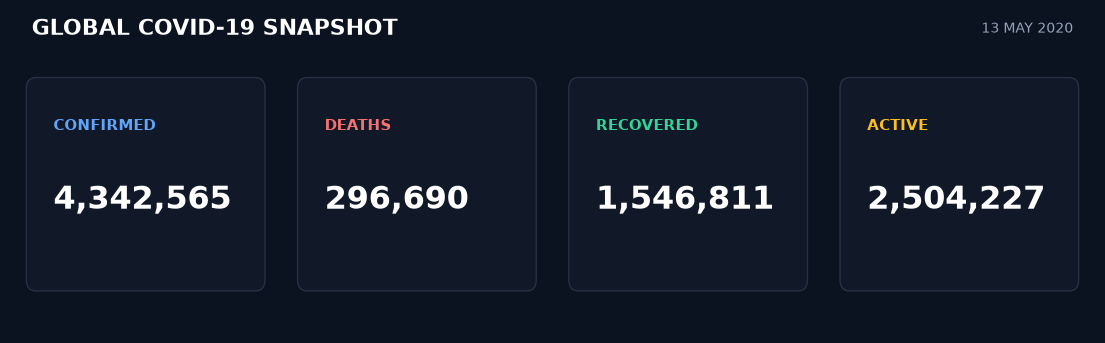

In [7]:
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(14, 4.2))
ax.set_xlim(0, 4)
ax.set_ylim(0, 1)
ax.axis("off")

fig.patch.set_facecolor("#0B1220")
ax.set_facecolor("#0B1220")

labels = ["CONFIRMED", "DEATHS", "RECOVERED", "ACTIVE"]
values = [
    global_totals["Confirmed"],
    global_totals["Deaths"],
    global_totals["Recovered"],
    global_totals["Active"],
]

accent_colors = ["#60A5FA", "#F87171", "#34D399", "#FBBF24"]

for i, (label, value, accent) in enumerate(zip(labels, values, accent_colors)):
    x = i + 0.08

    card = FancyBboxPatch(
        (x, 0.15),
        0.84,
        0.62,
        boxstyle="round,pad=0.02,rounding_size=0.035",
        linewidth=1,
        edgecolor="#263244",
        facecolor="#111827",
    )
    ax.add_patch(card)

    ax.text(
        x + 0.08, 0.64, label,
        fontsize=11,
        fontweight="bold",
        color=accent,
        ha="left",
        va="center",
    )

    ax.text(
        x + 0.08, 0.41, f"{value:,.0f}",
        fontsize=23,
        fontweight="bold",
        color="white",
        ha="left",
        va="center",
    )

ax.text(
    0.08, 0.94,
    "GLOBAL COVID-19 SNAPSHOT",
    fontsize=16,
    fontweight="bold",
    color="white",
    ha="left",
    va="center",
)

ax.text(
    3.92, 0.94,
    "13 MAY 2020",
    fontsize=10,
    color="#94A3B8",
    ha="right",
    va="center",
)

plt.show()

The May 13 snapshot records reported cumulative cases rather than estimates of
the pandemic's eventual scale. Differences in testing capacity, reporting
practices, and data availability across countries should be considered when
comparing these totals.

### Country-level patterns

Country rankings provide a clearer view of how reported case burden differed
across the most affected countries by May 13, 2020.

The original project explored these patterns through interactive tables,
bubble charts, and bar charts. The restored version consolidates those views
into a single interactive comparison of confirmed cases, deaths, and
recoveries.

In [8]:
top_confirmed = (
    CoV_country
    .nlargest(10, "confirmed")
    .sort_values("confirmed")
)

top_deaths = (
    CoV_country
    .nlargest(10, "deaths")
    .sort_values("deaths")
)

top_recovered = (
    CoV_country
    .nlargest(10, "recovered")
    .sort_values("recovered")
)

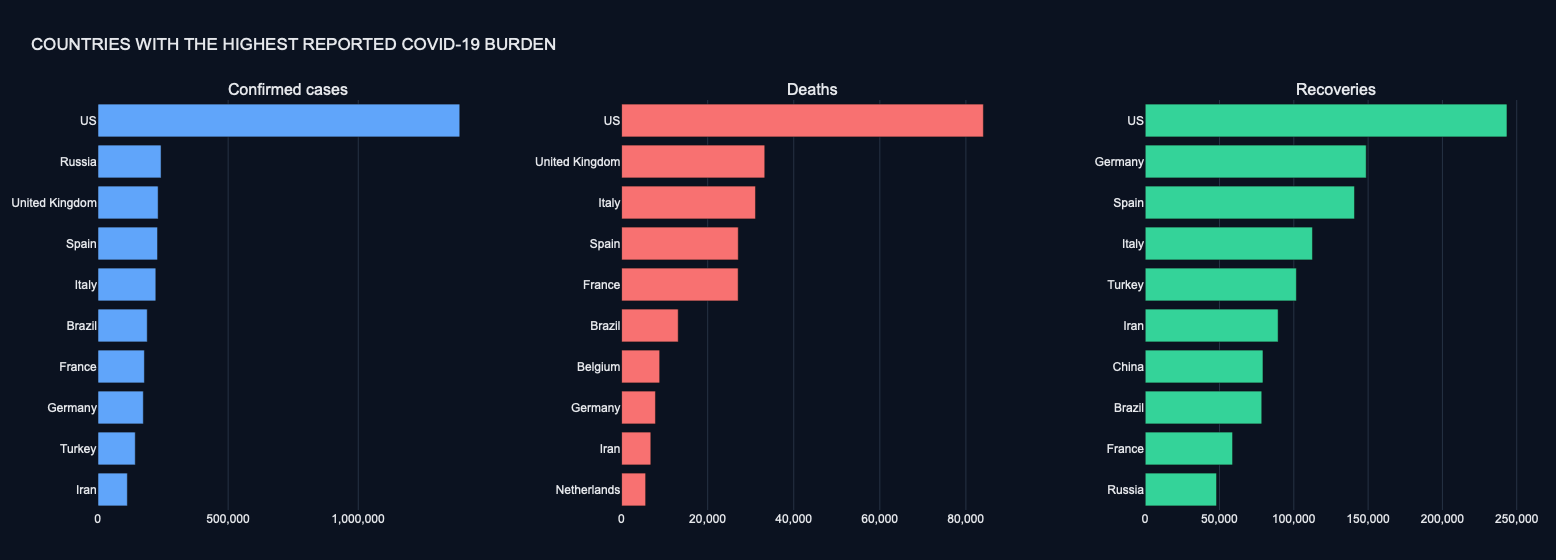

In [9]:
fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=(
        "Confirmed cases",
        "Deaths",
        "Recoveries",
    ),
    horizontal_spacing=0.10,
)

fig.add_trace(
    go.Bar(
        x=top_confirmed["confirmed"],
        y=top_confirmed["country"],
        orientation="h",
        marker_color="#60A5FA",
        customdata=top_confirmed[["deaths", "recovered", "active"]],
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Confirmed: %{x:,.0f}<br>"
            "Deaths: %{customdata[0]:,.0f}<br>"
            "Recovered: %{customdata[1]:,.0f}<br>"
            "Active: %{customdata[2]:,.0f}"
            "<extra></extra>"
        ),
        showlegend=False,
    ),
    row=1,
    col=1,
)

fig.add_trace(
    go.Bar(
        x=top_deaths["deaths"],
        y=top_deaths["country"],
        orientation="h",
        marker_color="#F87171",
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Deaths: %{x:,.0f}"
            "<extra></extra>"
        ),
        showlegend=False,
    ),
    row=1,
    col=2,
)

fig.add_trace(
    go.Bar(
        x=top_recovered["recovered"],
        y=top_recovered["country"],
        orientation="h",
        marker_color="#34D399",
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Recovered: %{x:,.0f}"
            "<extra></extra>"
        ),
        showlegend=False,
    ),
    row=1,
    col=3,
)

fig.update_layout(
    title={
        "text": "COUNTRIES WITH THE HIGHEST REPORTED COVID-19 BURDEN",
        "x": 0.02,
        "xanchor": "left",
    },
    template="plotly_dark",
    paper_bgcolor="#0B1220",
    plot_bgcolor="#0B1220",
    height=560,
    width=1200,
    margin=dict(l=60, r=30, t=100, b=50),
    font=dict(
        family="Arial",
        color="#E5E7EB",
    ),
)

fig.update_xaxes(
    showgrid=True,
    gridcolor="#263244",
    zeroline=False,
    tickformat=",",
)

fig.update_yaxes(
    showgrid=False,
)

fig.show()

The rankings show that the countries with the highest confirmed case counts
were not necessarily ranked identically by deaths or recoveries. These
differences reflect both the progression of outbreaks and substantial
variation in testing, reporting, and recovery definitions across countries.

### Geographic distribution

Reported cases were geographically widespread by mid-May 2020, but the
concentration of reported cases varied substantially across countries.

The map below uses the country-level latitude and longitude coordinates from
the historical JHU snapshot. Marker size reflects reported confirmed cases.

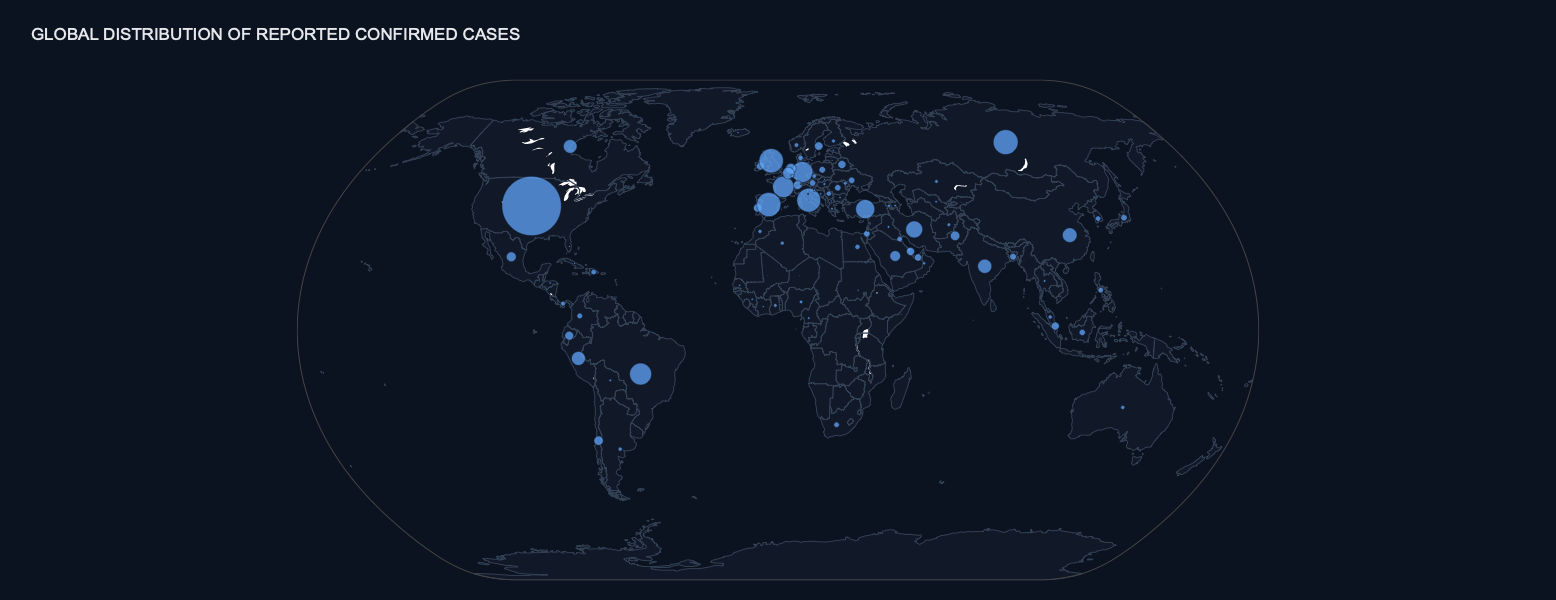

In [10]:
map_data = (
    CoV_country[
        ["country", "lat", "long", "confirmed", "deaths", "recovered"]
    ]
    .dropna(subset=["lat", "long", "confirmed"])
    .copy()
)

fig = px.scatter_geo(
    map_data,
    lat="lat",
    lon="long",
    size="confirmed",
    hover_name="country",
    hover_data={
        "confirmed": ":,.0f",
        "deaths": ":,.0f",
        "recovered": ":,.0f",
        "lat": False,
        "long": False,
    },
    size_max=42,
    projection="natural earth",
)

fig.update_traces(
    marker=dict(
        color="#60A5FA",
        line=dict(width=0.5, color="#0B1220"),
        opacity=0.75,
    )
)

fig.update_geos(
    showcoastlines=False,
    showcountries=True,
    countrycolor="#334155",
    showland=True,
    landcolor="#111827",
    showocean=True,
    oceancolor="#0B1220",
    bgcolor="#0B1220",
)

fig.update_layout(
    title={
        "text": "GLOBAL DISTRIBUTION OF REPORTED CONFIRMED CASES",
        "x": 0.02,
        "xanchor": "left",
    },
    paper_bgcolor="#0B1220",
    font=dict(
        family="Arial",
        color="#E5E7EB",
    ),
    height=600,
    margin=dict(l=20, r=20, t=80, b=20),
)

fig.show()

The map emphasizes the uneven geographic concentration of reported cases rather
than implying that marker size represents true infection prevalence. Cross-country
differences in testing coverage and reporting practices remain important
limitations of the comparison.

### Population-adjusted comparison

Raw case counts can obscure differences in country size. To add context, the
original project compared reported confirmed cases with 2018 population data
from the World Bank.

The restored analysis retains the same eight-country comparison while matching
COVID-19 and population records explicitly by country name rather than by
dataframe row position.

The resulting percentages represent **reported confirmed cases as a share of
2018 population**. They should not be interpreted as estimates of true infection
prevalence.

In [11]:
population = pd.read_csv(
    RAW_DATA_DIR / "country_population_2018.csv"
)

population_2018 = (
    population[["Country Name", "2018"]]
    .rename(
        columns={
            "Country Name": "population_country",
            "2018": "population_2018",
        }
    )
)

selected_countries = [
    "US",
    "Italy",
    "China",
    "Sweden",
    "New Zealand",
    "Korea, South",
    "Argentina",
    "India",
]

country_name_map = {
    "US": "United States",
    "Korea, South": "Korea, Rep.",
}

population_comparison = (
    CoV_country.loc[
        CoV_country["country"].isin(selected_countries),
        ["country", "confirmed", "deaths", "recovered", "active"],
    ]
    .copy()
)

population_comparison["population_country"] = (
    population_comparison["country"]
    .replace(country_name_map)
)

population_comparison = population_comparison.merge(
    population_2018,
    on="population_country",
    how="left",
    validate="one_to_one",
)

population_comparison["confirmed_pct_population"] = (
    population_comparison["confirmed"]
    / population_comparison["population_2018"]
    * 100
)

population_comparison[
    [
        "country",
        "confirmed",
        "population_2018",
        "confirmed_pct_population",
    ]
].sort_values(
    "confirmed_pct_population",
    ascending=False,
)

,country,confirmed,population_2018,confirmed_pct_population
3,US,1389935,3.266875e+08,0.425463
1,Italy,222104,6.042176e+07,0.367589
2,Sweden,27909,1.017521e+07,0.274284
7,New Zealand,1497,4.841000e+06,0.030923
6,"Korea, South",10962,5.160663e+07,0.021241
4,Argentina,6879,4.449450e+07,0.015460
0,China,84021,1.392730e+09,0.006033
5,India,78055,1.352617e+09,0.005771


In [12]:
assert population_comparison["population_2018"].notna().all()
assert len(population_comparison) == 8

print("All eight selected countries matched successfully.")

All eight selected countries matched successfully.


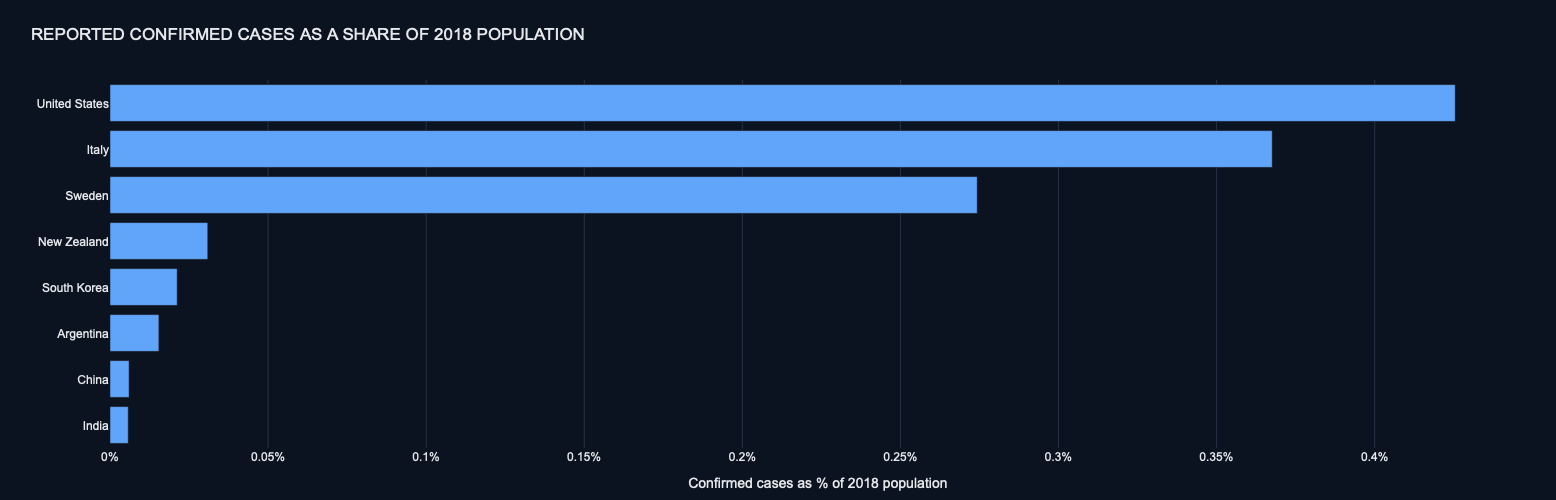

In [13]:
population_plot = (
    population_comparison
    .sort_values("confirmed_pct_population")
    .copy()
)

# Presentation-friendly labels only;
# underlying historical country names remain unchanged.
population_plot["display_country"] = (
    population_plot["country"]
    .replace(
        {
            "US": "United States",
            "Korea, South": "South Korea",
        }
    )
)

fig = go.Figure(
    go.Bar(
        x=population_plot["confirmed_pct_population"],
        y=population_plot["display_country"],
        orientation="h",
        marker_color="#60A5FA",
        customdata=population_plot[
            ["confirmed", "population_2018"]
        ],
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Confirmed cases: %{customdata[0]:,.0f}<br>"
            "2018 population: %{customdata[1]:,.0f}<br>"
            "Reported cases / population: %{x:.3f}%"
            "<extra></extra>"
        ),
    )
)

fig.update_layout(
    title={
        "text": "REPORTED CONFIRMED CASES AS A SHARE OF 2018 POPULATION",
        "x": 0.02,
        "xanchor": "left",
    },
    template="plotly_dark",
    paper_bgcolor="#0B1220",
    plot_bgcolor="#0B1220",
    height=500,
    margin=dict(l=80, r=30, t=80, b=50),
    font=dict(
        family="Arial",
        color="#E5E7EB",
    ),
    xaxis_title="Confirmed cases as % of 2018 population",
    yaxis_title="",
)

fig.update_xaxes(
    gridcolor="#263244",
    zeroline=False,
    ticksuffix="%",
)

fig.show()

Adjusting for population changes the comparison substantially: countries with
the largest absolute case totals are not necessarily those with the largest
reported case burden relative to population size.

This comparison remains dependent on differences in testing and reporting
between countries and uses 2018 population figures, consistent with the
historical project.

### COVID-19 progression over time

The original project included an animated bar-chart race showing how the
countries with the highest reported confirmed case counts changed during the
early months of the pandemic.

The visualization was developed by a teammate after it was proposed as an
additional project feature. The implementation was adapted from bar-chart-race
examples by **Pratap Vardhan** and **John Burn-Murdoch**, whose work was also
credited in the original 2020 notebook.

For computational efficiency and consistency with the historical project, the
animation begins on February 25, 2020.

In [14]:
import matplotlib.animation as animation
import matplotlib.ticker as ticker

# Historical date columns in the frozen JHU dataset
non_date_columns = {"state", "country", "lat", "long"}

date_columns = [
    col
    for col in CoV_confirmed.columns
    if col not in non_date_columns
]

parsed_dates = pd.to_datetime(
    date_columns,
    format="%m/%d/%y"
)

animation_dates = [
    col
    for col, date in zip(date_columns, parsed_dates)
    if date >= pd.Timestamp("2020-02-25")
]

# Work from a contiguous copy before aggregating province/state rows
confirmed_base = (
    CoV_confirmed[
        ["country"] + date_columns
    ]
    .copy()
)

confirmed_country = (
    confirmed_base
    .groupby("country", as_index=False)[date_columns]
    .sum()
)

# Countries with the highest totals at the end of the analysis window
animation_countries = (
    confirmed_country
    .nlargest(14, date_columns[-1])["country"]
    .tolist()
)

confirmed_animation = (
    confirmed_country[
        confirmed_country["country"].isin(animation_countries)
    ]
    .melt(
        id_vars="country",
        value_vars=animation_dates,
        var_name="date",
        value_name="confirmed",
    )
)

confirmed_animation["date"] = pd.to_datetime(
    confirmed_animation["date"],
    format="%m/%d/%y"
)

frame_dates = (
    confirmed_animation["date"]
    .drop_duplicates()
    .sort_values()
    .tolist()
)

print("Animation period:")
print(frame_dates[0], "to", frame_dates[-1])
print("Frames:", len(frame_dates))

Animation period:
2020-02-25 00:00:00 to 2020-05-13 00:00:00
Frames: 79


In [15]:
animation_colors = {
    country: color
    for country, color in zip(
        animation_countries,
        plt.cm.tab20.colors,
    )
}

display_country_names = {
    "US": "United States",
    "Korea, South": "South Korea",
}

fig, ax = plt.subplots(figsize=(12, 7))

def draw_barchart(date):
    frame = (
        confirmed_animation[
            confirmed_animation["date"].eq(date)
        ]
        .sort_values("confirmed", ascending=True)
        .tail(12)
        .copy()
    )

    frame["display_country"] = (
        frame["country"]
        .replace(display_country_names)
    )

    ax.clear()

    fig.patch.set_facecolor("#0B1220")
    ax.set_facecolor("#0B1220")

    ax.barh(
        frame["display_country"],
        frame["confirmed"],
        color=[
            animation_colors[country]
            for country in frame["country"]
        ],
    )

    max_value = max(frame["confirmed"].max(), 1)
    offset = max_value / 80

    for i, value in enumerate(frame["confirmed"]):
        ax.text(
            value + offset,
            i,
            f"{value:,.0f}",
            va="center",
            color="#E5E7EB",
            fontsize=10,
        )

    ax.text(
        0.98,
        0.08,
        pd.Timestamp(date).strftime("%d %b %Y").upper(),
        transform=ax.transAxes,
        ha="right",
        color="#94A3B8",
        fontsize=24,
        fontweight="bold",
    )

    ax.set_title(
        "COUNTRIES WITH THE HIGHEST REPORTED CONFIRMED CASES",
        loc="left",
        color="white",
        fontsize=15,
        fontweight="bold",
        pad=18,
    )

    ax.xaxis.set_major_formatter(
        ticker.StrMethodFormatter("{x:,.0f}")
    )

    ax.tick_params(axis="x", colors="#94A3B8")
    ax.tick_params(axis="y", colors="#E5E7EB")

    ax.grid(
        axis="x",
        color="#263244",
        linewidth=0.7,
        alpha=0.8,
    )

    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_visible(False)

plt.close(fig)

In [16]:
ASSETS_DIR = PROJECT_ROOT / "assets"
ASSETS_DIR.mkdir(exist_ok=True)

animation_path = ASSETS_DIR / "covid_country_progression.gif"

animator = animation.FuncAnimation(
    fig,
    draw_barchart,
    frames=frame_dates,
    interval=125,
    repeat=False,
)

writer = animation.PillowWriter(
    fps=8
)

animator.save(
    animation_path,
    writer=writer,
    dpi=80,
)

print(
    "Animation saved to:",
    animation_path.relative_to(PROJECT_ROOT),
)

Animation saved to: assets/covid_country_progression.gif


#### Animated country progression

![Animated progression of reported confirmed COVID-19 cases](../assets/covid_country_progression.gif)

The animation shows how the concentration of reported confirmed cases shifted
across countries between February 25 and May 13, 2020. China dominated the
early ranking, followed by a rapid shift toward European countries and the
United States as reported case counts increased across different regions.

As with the other cross-country comparisons, the animation reflects reported
confirmed cases rather than true infection prevalence.

## 02 · United States

The global analysis showed that the United States had the highest reported
confirmed case total by May 13, 2020. This section looks more closely at how
reported cases were distributed across US states and how national daily case
counts evolved during the historical project period.

State and county-level confirmed-case data are drawn from the same frozen
Johns Hopkins University snapshot used in the global analysis. Daily national
case counts come from the historical CDC-based dataset assembled for the
original project.

In [17]:
CoV_US_Confirmed = pd.read_csv(
    JHU_DATA_DIR / "time_series_covid19_confirmed_US.csv"
)

CoV_US_deaths = pd.read_csv(
    JHU_DATA_DIR / "time_series_covid19_deaths_US.csv"
)

print("US confirmed:", CoV_US_Confirmed.shape)
print("US deaths:", CoV_US_deaths.shape)
print("Confirmed time series through:", CoV_US_Confirmed.columns[-1])
print("Deaths time series through:", CoV_US_deaths.columns[-1])

US confirmed: (3261, 124)
US deaths: (3261, 125)
Confirmed time series through: 5/13/20
Deaths time series through: 5/13/20


### State-level case burden

The original project ranked states by cumulative confirmed cases. The restored
version performs the same comparison while explicitly aggregating county-level
records to state totals.

In [18]:
# Standardize column names
CoV_US_Confirmed.columns = CoV_US_Confirmed.columns.str.lower()
CoV_US_deaths.columns = CoV_US_deaths.columns.str.lower()

CoV_US_Confirmed = CoV_US_Confirmed.rename(
    columns={"long_": "long"}
)

CoV_US_deaths = CoV_US_deaths.rename(
    columns={"long_": "long"}
)

us_snapshot_date = "5/13/20"

state_confirmed = (
    CoV_US_Confirmed
    .groupby("province_state", as_index=False)[us_snapshot_date]
    .sum()
    .rename(columns={us_snapshot_date: "confirmed"})
)

state_deaths = (
    CoV_US_deaths
    .groupby("province_state", as_index=False)[us_snapshot_date]
    .sum()
    .rename(columns={us_snapshot_date: "deaths"})
)

state_summary = (
    state_confirmed
    .merge(
        state_deaths,
        on="province_state",
        how="left",
        validate="one_to_one",
    )
    .sort_values("confirmed", ascending=False)
)

state_summary.head(10)

,province_state,confirmed,deaths
36,New York,340661,27477
34,New Jersey,141560,9714
17,Illinois,84694,3792
25,Massachusetts,80497,5315
5,California,72798,2957
43,Pennsylvania,62101,4094
26,Michigan,48391,4714
49,Texas,43020,1172
11,Florida,42402,1827
12,Georgia,35427,1517


In [19]:
assert CoV_US_Confirmed.columns[-1] == "5/13/20"
assert CoV_US_deaths.columns[-1] == "5/13/20"

print("US historical snapshot validated.")

US historical snapshot validated.


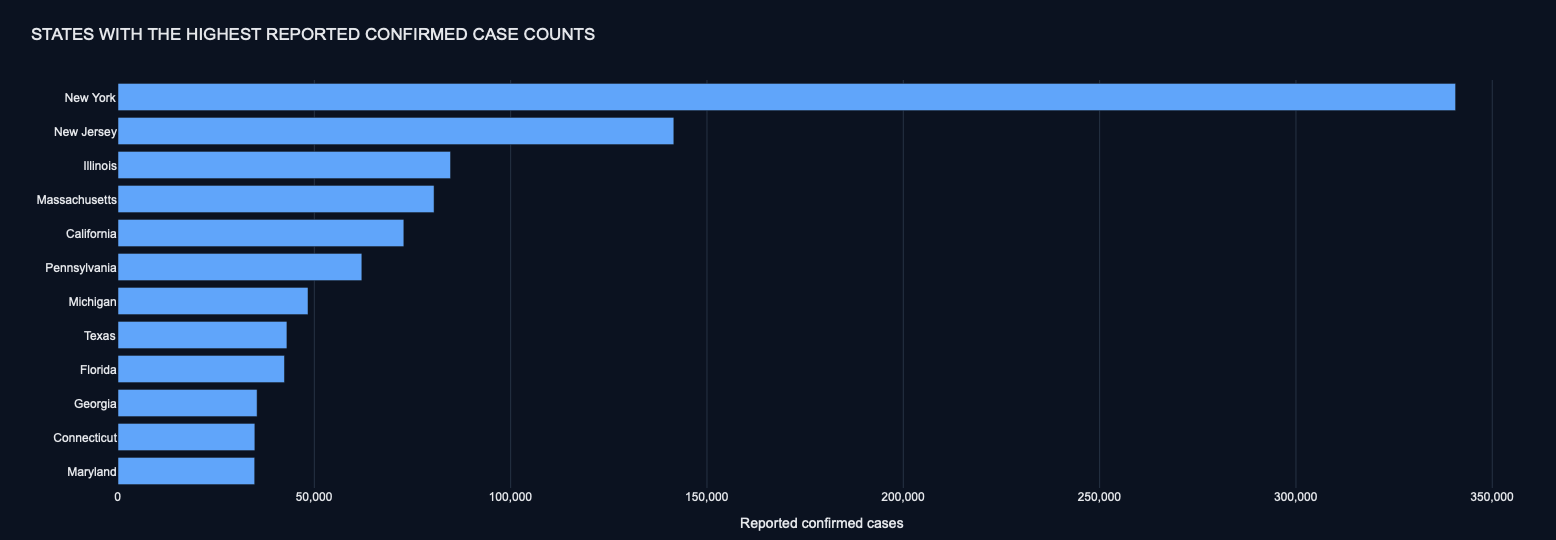

In [20]:
top_states = (
    state_summary
    .head(12)
    .sort_values("confirmed")
)

fig = go.Figure(
    go.Bar(
        x=top_states["confirmed"],
        y=top_states["province_state"],
        orientation="h",
        marker_color="#60A5FA",
        customdata=top_states[["deaths"]],
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Confirmed cases: %{x:,.0f}<br>"
            "Deaths: %{customdata[0]:,.0f}"
            "<extra></extra>"
        ),
    )
)

fig.update_layout(
    title={
        "text": "STATES WITH THE HIGHEST REPORTED CONFIRMED CASE COUNTS",
        "x": 0.02,
        "xanchor": "left",
    },
    template="plotly_dark",
    paper_bgcolor="#0B1220",
    plot_bgcolor="#0B1220",
    height=540,
    margin=dict(l=100, r=30, t=80, b=50),
    font=dict(
        family="Arial",
        color="#E5E7EB",
    ),
    xaxis_title="Reported confirmed cases",
    yaxis_title="",
)

fig.update_xaxes(
    gridcolor="#263244",
    zeroline=False,
    tickformat=",",
)

fig.show()

Reported case burden was highly concentrated across a relatively small number
of states by mid-May 2020, with New York standing far above the rest of the
country in cumulative confirmed cases.

These totals reflect reported cases rather than population-adjusted infection
rates and are influenced by differences in testing and reporting across states.

### Geographic distribution

County-level coordinates provide additional context on where reported confirmed
cases were concentrated across the United States.

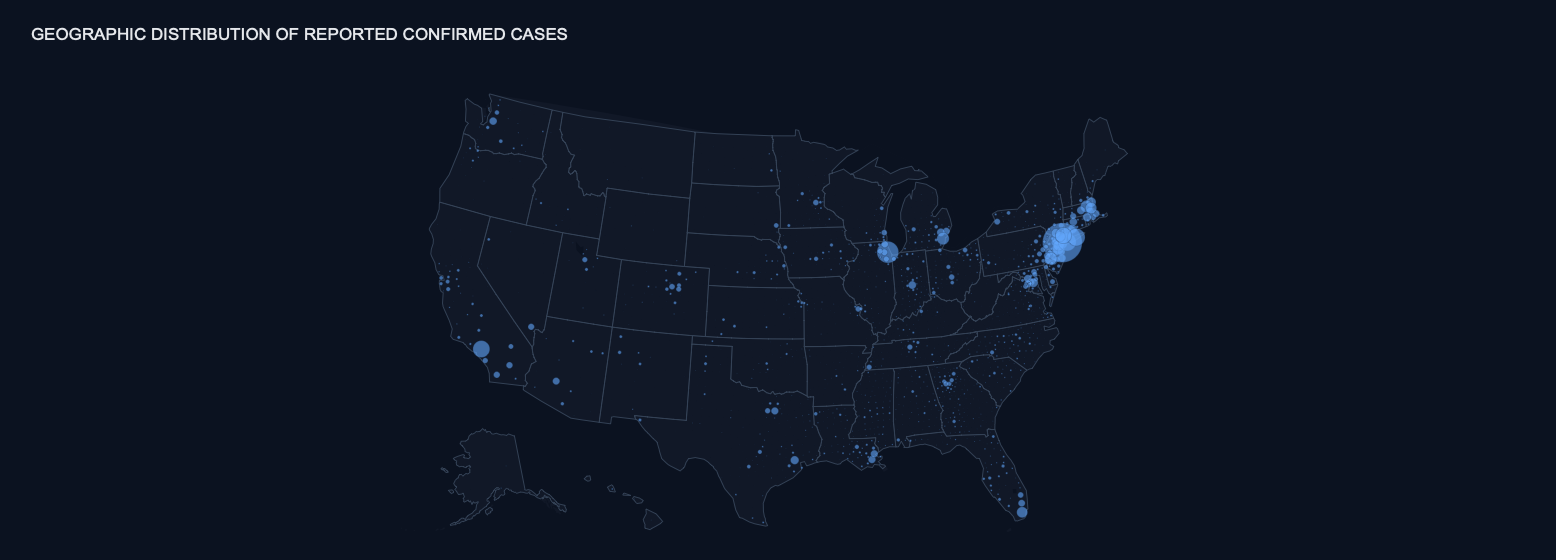

In [21]:
us_map_data = (
    CoV_US_Confirmed[
        ["province_state", "admin2", "lat", "long", us_snapshot_date]
    ]
    .rename(columns={us_snapshot_date: "confirmed"})
    .dropna(subset=["lat", "long"])
    .copy()
)

us_map_data = us_map_data[
    us_map_data["confirmed"] > 0
]

fig = px.scatter_geo(
    us_map_data,
    lat="lat",
    lon="long",
    size="confirmed",
    hover_name="admin2",
    hover_data={
        "province_state": True,
        "confirmed": ":,.0f",
        "lat": False,
        "long": False,
    },
    scope="usa",
    size_max=28,
)

fig.update_traces(
    marker=dict(
        color="#60A5FA",
        opacity=0.60,
        line=dict(
            width=0.3,
            color="#0B1220",
        ),
    )
)

fig.update_geos(
    bgcolor="#0B1220",
    landcolor="#111827",
    lakecolor="#0B1220",
    subunitcolor="#334155",
    countrycolor="#334155",
)

fig.update_layout(
    title={
        "text": "GEOGRAPHIC DISTRIBUTION OF REPORTED CONFIRMED CASES",
        "x": 0.02,
        "xanchor": "left",
    },
    paper_bgcolor="#0B1220",
    font=dict(
        family="Arial",
        color="#E5E7EB",
    ),
    height=560,
    margin=dict(l=20, r=20, t=80, b=20),
)

fig.show()

### Daily reported cases

State-level cumulative totals show where reported cases were concentrated, while
daily national case counts provide a view of how reported infections evolved
through the early months of the US outbreak.

The original project assembled this historical series from CDC figures available
during Spring 2020. The restored analysis uses the preserved project dataset
rather than reconstructing the series from current sources.

In [22]:
daily_us = pd.read_csv(
    RAW_DATA_DIR / "daily_new_covid_usa.csv"
)

print("Shape:", daily_us.shape)
print("Columns:", daily_us.columns.tolist())

display(daily_us.head())
display(daily_us.tail())

Shape: (77, 2)
Columns: ['Date', 'Cases']


,Date,Cases
0,2/25/20,0
1,2/26/20,0
2,2/27/20,1
3,2/28/20,0
4,2/29/20,8


,Date,Cases
72,5/7/20,28974
73,5/8/20,25996
74,5/9/20,26660
75,5/10/20,23792
76,5/11/20,18106


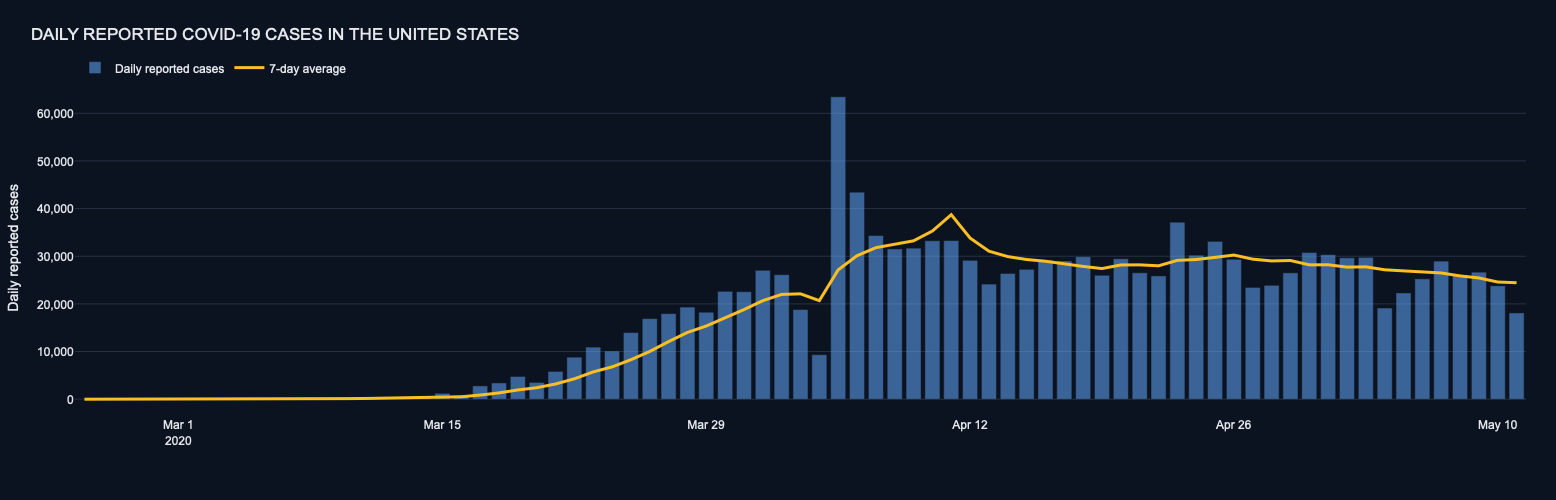

In [23]:
daily_us["Date"] = pd.to_datetime(
    daily_us["Date"],
    format="%m/%d/%y"
)

daily_us = (
    daily_us
    .sort_values("Date")
    .reset_index(drop=True)
)

# Seven-day average added only to make the daily trend easier to read.
daily_us["7_day_average"] = (
    daily_us["Cases"]
    .rolling(window=7, min_periods=1)
    .mean()
)

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=daily_us["Date"],
        y=daily_us["Cases"],
        name="Daily reported cases",
        marker_color="#60A5FA",
        opacity=0.55,
        hovertemplate=(
            "<b>%{x|%d %b %Y}</b><br>"
            "Daily cases: %{y:,.0f}"
            "<extra></extra>"
        ),
    )
)

fig.add_trace(
    go.Scatter(
        x=daily_us["Date"],
        y=daily_us["7_day_average"],
        mode="lines",
        name="7-day average",
        line=dict(
            color="#FBBF24",
            width=3,
        ),
        hovertemplate=(
            "<b>%{x|%d %b %Y}</b><br>"
            "7-day average: %{y:,.0f}"
            "<extra></extra>"
        ),
    )
)

fig.update_layout(
    title={
        "text": "DAILY REPORTED COVID-19 CASES IN THE UNITED STATES",
        "x": 0.02,
        "xanchor": "left",
    },
    template="plotly_dark",
    paper_bgcolor="#0B1220",
    plot_bgcolor="#0B1220",
    height=500,
    margin=dict(l=60, r=30, t=80, b=60),
    font=dict(
        family="Arial",
        color="#E5E7EB",
    ),
    xaxis_title="",
    yaxis_title="Daily reported cases",
    legend=dict(
        orientation="h",
        y=1.08,
        x=0,
    ),
)

fig.update_xaxes(
    showgrid=False,
)

fig.update_yaxes(
    gridcolor="#263244",
    zeroline=False,
    tickformat=",",
)

fig.show()

Daily reported case counts increased sharply during March and remained elevated
through April and early May 2020. Day-to-day reporting was volatile, so the
seven-day average is included to make the broader trajectory easier to see.

The series should be interpreted as reported case activity rather than the true
number of infections, particularly given changes in testing availability and
reporting practices during the early US outbreak.

## 03 · New York City

New York City was one of the earliest and most heavily affected US population
centers during the first wave of COVID-19.

This section examines three dimensions of the city's reported outbreak during
the historical project period:

- daily reported cases, hospitalizations, and deaths;
- differences across age groups;
- differences by sex.

The analysis uses locally preserved snapshots from the New York City Department
of Health and Mental Hygiene COVID-19 repository, pinned to the historical
repository state used by the original project.

### Historical NYC data

In [24]:
NYC_DATA_DIR = RAW_DATA_DIR / "nyc"

nyc_daily = pd.read_csv(
    NYC_DATA_DIR / "case-hosp-death.csv"
)

nyc_age = pd.read_csv(
    NYC_DATA_DIR / "by-age.csv"
)

nyc_sex = pd.read_csv(
    NYC_DATA_DIR / "by-sex.csv"
)

print("Daily data:", nyc_daily.shape)
print("Daily columns:", nyc_daily.columns.tolist())

print()
print("Age data:", nyc_age.shape)
print("Age columns:", nyc_age.columns.tolist())

print()
print("Sex data:", nyc_sex.shape)
print("Sex columns:", nyc_sex.columns.tolist())

Daily data: (73, 4)
Daily columns: ['DATE_OF_INTEREST', 'CASE_COUNT', 'HOSPITALIZED_COUNT', 'DEATH_COUNT']

Age data: (6, 4)
Age columns: ['AGE_GROUP', 'COVID_CASE_RATE', 'HOSPITALIZED_CASE_RATE', 'DEATH_RATE']

Sex data: (3, 4)
Sex columns: ['SEX_GROUP', 'COVID_CASE_RATE', 'HOSPITALIZED_CASE_RATE', 'DEATH_RATE']


### Daily outbreak patterns

Daily reported cases, hospitalizations, and deaths provide complementary views
of the first major COVID-19 wave in New York City.

Because daily reporting can be volatile and recent observations may be affected
by reporting delays, seven-day averages are included to emphasize the broader
trajectory rather than individual daily fluctuations.

In [25]:
nyc_daily["DATE_OF_INTEREST"] = pd.to_datetime(
    nyc_daily["DATE_OF_INTEREST"],
    format="%m/%d/%y"
)

nyc_daily = (
    nyc_daily
    .sort_values("DATE_OF_INTEREST")
    .reset_index(drop=True)
)

for metric in [
    "CASE_COUNT",
    "HOSPITALIZED_COUNT",
    "DEATH_COUNT",
]:
    nyc_daily[f"{metric}_7DAY"] = (
        nyc_daily[metric]
        .rolling(window=7, min_periods=1)
        .mean()
    )

assert nyc_daily["DATE_OF_INTEREST"].iloc[-1] == pd.Timestamp("2020-05-11")
assert nyc_daily.iloc[-1]["CASE_COUNT"] == 26
assert nyc_daily.iloc[-1]["HOSPITALIZED_COUNT"] == 0
assert nyc_daily.iloc[-1]["DEATH_COUNT"] == 3

print("Historical NYC daily series validated.")

Historical NYC daily series validated.


Reported cases, hospitalizations, and deaths rose sharply during the first NYC
wave and later declined within the historical series.

The timing and magnitude of those changes differ across the three measures.
Recent daily observations in the dataset should be interpreted cautiously
because reporting delays can make the latest values appear artificially low.

### Patterns by age

The historical NYC Health snapshot also reported COVID-19 case,
hospitalization, and death rates across age groups.

The citywide aggregate is excluded from the comparison below so that the age
groups can be compared directly.

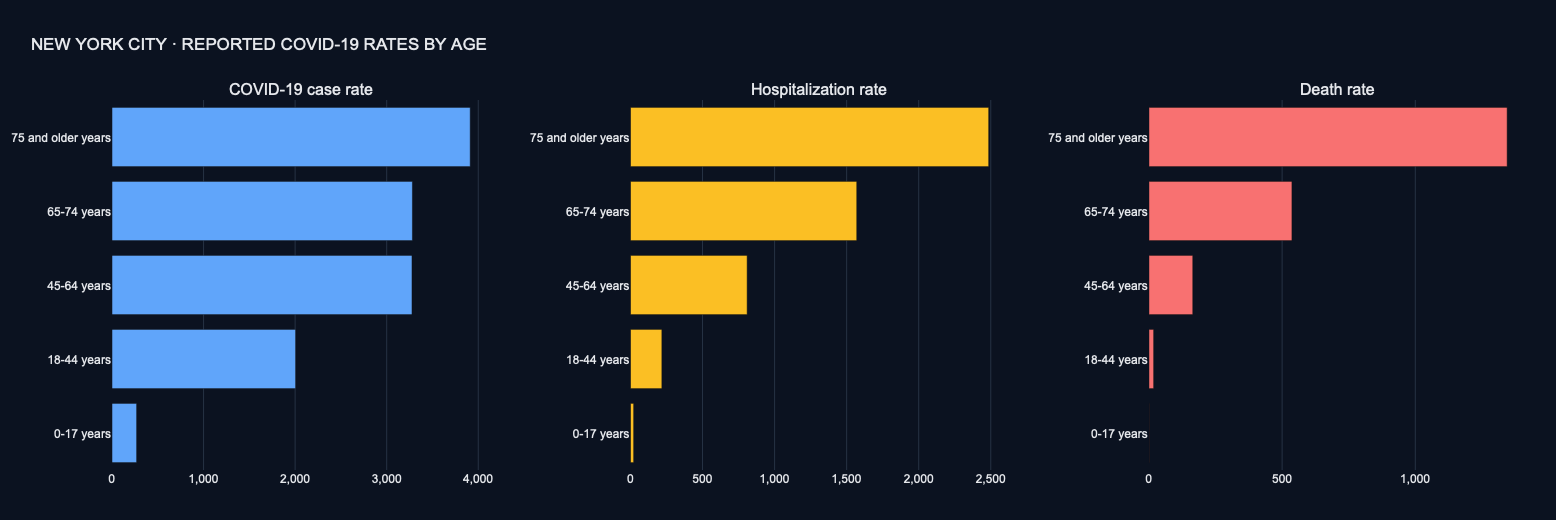

In [26]:
nyc_age_plot = (
    nyc_age[
        nyc_age["AGE_GROUP"] != "Citywide total"
    ]
    .copy()
)

fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=(
        "COVID-19 case rate",
        "Hospitalization rate",
        "Death rate",
    ),
    horizontal_spacing=0.10,
)

age_metrics = [
    ("COVID_CASE_RATE", "#60A5FA"),
    ("HOSPITALIZED_CASE_RATE", "#FBBF24"),
    ("DEATH_RATE", "#F87171"),
]

for col, (metric, color) in enumerate(age_metrics, start=1):
    plot_data = (
        nyc_age_plot
        .sort_values(metric)
    )

    fig.add_trace(
        go.Bar(
            x=plot_data[metric],
            y=plot_data["AGE_GROUP"],
            orientation="h",
            marker_color=color,
            hovertemplate=(
                "<b>%{y}</b><br>"
                "Reported rate: %{x:,.2f}"
                "<extra></extra>"
            ),
            showlegend=False,
        ),
        row=1,
        col=col,
    )

fig.update_layout(
    title={
        "text": "NEW YORK CITY · REPORTED COVID-19 RATES BY AGE",
        "x": 0.02,
        "xanchor": "left",
    },
    template="plotly_dark",
    paper_bgcolor="#0B1220",
    plot_bgcolor="#0B1220",
    height=520,
    margin=dict(l=80, r=30, t=100, b=50),
    font=dict(
        family="Arial",
        color="#E5E7EB",
    ),
)

fig.update_xaxes(
    gridcolor="#263244",
    zeroline=False,
    tickformat=",",
)

fig.update_yaxes(showgrid=False)

fig.show()

The historical age profile shows a pronounced increase in severe-outcome rates
with age. The oldest groups had substantially higher hospitalization and death
rates than younger groups within the May 2020 NYC Health snapshot.

These figures describe the reported historical data and should not be interpreted
as estimates of individual risk independent of other factors.

### Patterns by sex

The same historical NYC Health snapshot reported case, hospitalization, and
death rates by sex. The citywide aggregate is again excluded so the two reported
groups can be compared directly.

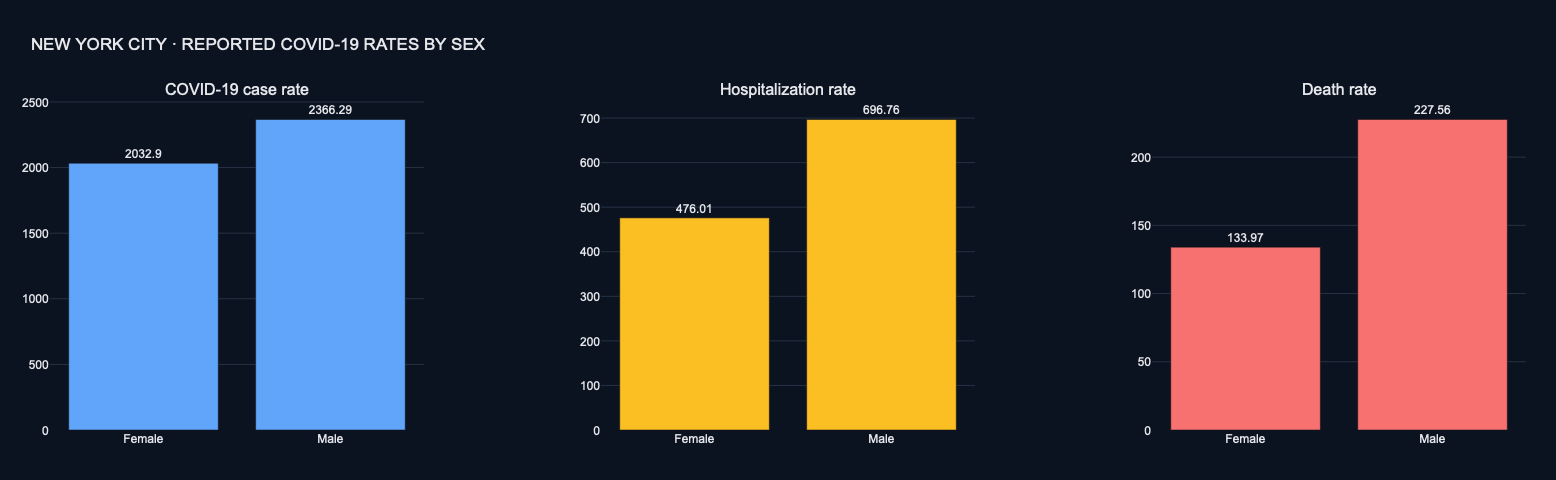

In [27]:
nyc_sex_plot = (
    nyc_sex[
        nyc_sex["SEX_GROUP"] != "Citywide total"
    ]
    .copy()
)

fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=(
        "COVID-19 case rate",
        "Hospitalization rate",
        "Death rate",
    ),
    horizontal_spacing=0.12,
)

sex_metrics = [
    ("COVID_CASE_RATE", "#60A5FA"),
    ("HOSPITALIZED_CASE_RATE", "#FBBF24"),
    ("DEATH_RATE", "#F87171"),
]

for col, (metric, color) in enumerate(sex_metrics, start=1):
    fig.add_trace(
        go.Bar(
            x=nyc_sex_plot["SEX_GROUP"],
            y=nyc_sex_plot[metric],
            marker_color=color,
            text=nyc_sex_plot[metric].round(2),
            textposition="outside",
            hovertemplate=(
                "<b>%{x}</b><br>"
                "Reported rate: %{y:,.2f}"
                "<extra></extra>"
            ),
            showlegend=False,
        ),
        row=1,
        col=col,
    )

fig.update_layout(
    title={
        "text": "NEW YORK CITY · REPORTED COVID-19 RATES BY SEX",
        "x": 0.02,
        "xanchor": "left",
    },
    template="plotly_dark",
    paper_bgcolor="#0B1220",
    plot_bgcolor="#0B1220",
    height=480,
    margin=dict(l=50, r=30, t=100, b=50),
    font=dict(
        family="Arial",
        color="#E5E7EB",
    ),
)

fig.update_yaxes(
    gridcolor="#263244",
    zeroline=False,
)

fig.show()

In this historical NYC snapshot, the reported case, hospitalization, and death
rates were all higher for males than for females, with the difference becoming
more pronounced for hospitalization and death rates.

As with the age comparison, these descriptive rates do not establish why the
differences occurred.

## 04 · State-Level Testing Regression

The original project used exploratory ordinary least squares (OLS) regression
to examine how reported state-level COVID-19 testing volumes were associated
with selected state characteristics.

The dependent variable was **Tested**, representing the number of people tested
for COVID-19 in each state. Five predictors were examined individually:

- **Physicians** — number of physicians in the state
- **Health_Spending** — annual health spending
- **Income** — median income
- **Pollution** — pollution index
- **Population** — state population

The regression work was developed by a teammate as part of the original
three-person project.

> **Restoration note:** The recovered archive contains the original composite
> `COVID19_state metrics.csv` file, but its source provenance is not documented
> clearly enough to redistribute it confidently. The restored notebook therefore
> reports the regression results preserved in the executed 2020 project rather
> than presenting the analysis as a newly reproduced model fit.

### Simple regression results

Each predictor was first examined separately using a simple linear regression.

The comparison below summarizes the original Spring 2020 model outputs.

In [28]:
simple_regression_results = pd.DataFrame(
    {
        "Predictor": [
            "Physicians",
            "Health spending",
            "Income",
            "Pollution",
            "Population",
        ],
        "R_squared": [
            0.603,
            0.004,
            0.148,
            0.050,
            0.397,
        ],
        "model_p_value": [
            2.19e-11,
            0.675,
            0.00537,
            0.114,
            7.17e-07,
        ],
    }
)

simple_regression_results["Statistically significant"] = (
    simple_regression_results["model_p_value"] < 0.05
)

simple_regression_results

,Predictor,R_squared,model_p_value,Statistically significant
0,Physicians,0.603,2.190000e-11,True
1,Health spending,0.004,6.750000e-01,False
2,Income,0.148,5.370000e-03,True
3,Pollution,0.050,1.140000e-01,False
4,Population,0.397,7.170000e-07,True


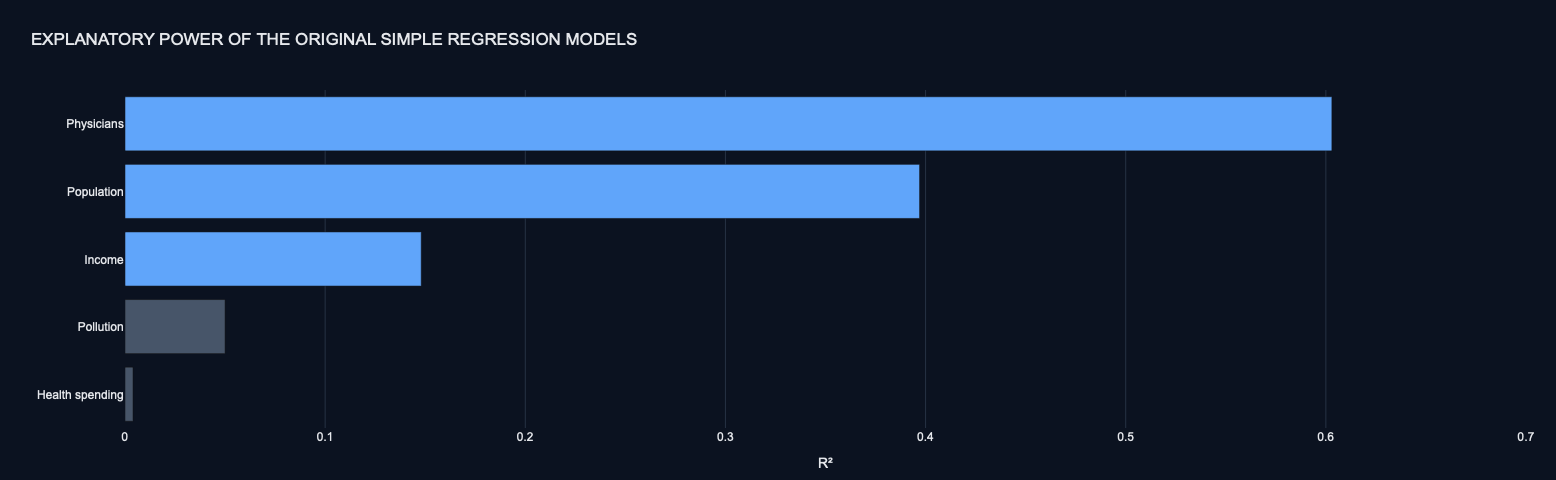

In [29]:
plot_data = simple_regression_results.sort_values(
    "R_squared",
    ascending=True,
)

bar_colors = [
    "#60A5FA" if significant else "#475569"
    for significant in plot_data["Statistically significant"]
]

fig = go.Figure(
    go.Bar(
        x=plot_data["R_squared"],
        y=plot_data["Predictor"],
        orientation="h",
        marker_color=bar_colors,
        customdata=plot_data[
            ["model_p_value", "Statistically significant"]
        ],
        hovertemplate=(
            "<b>%{y}</b><br>"
            "R²: %{x:.3f}<br>"
            "Model p-value: %{customdata[0]:.3g}<br>"
            "Significant at 0.05: %{customdata[1]}"
            "<extra></extra>"
        ),
    )
)

fig.update_layout(
    title={
        "text": "EXPLANATORY POWER OF THE ORIGINAL SIMPLE REGRESSION MODELS",
        "x": 0.02,
        "xanchor": "left",
    },
    template="plotly_dark",
    paper_bgcolor="#0B1220",
    plot_bgcolor="#0B1220",
    height=480,
    margin=dict(l=110, r=30, t=90, b=50),
    font=dict(
        family="Arial",
        color="#E5E7EB",
    ),
    xaxis_title="R²",
    yaxis_title="",
)

fig.update_xaxes(
    range=[0, 0.7],
    gridcolor="#263244",
    zeroline=False,
)

fig.show()

Among the five simple models, physician count showed the strongest association
with reported testing volume, explaining about 60% of the observed variation in
the original state-level sample. Population also showed a substantial positive
association, while income had a weaker but statistically significant relationship.

Health spending and pollution were not statistically significant in their
individual models.

These relationships are **associative rather than causal**. States with more
physicians or larger populations also differ in many other ways that may affect
testing capacity and reported testing volume.

### Multiple regression

The original analysis next combined the predictors that were significant in
the simple regressions: physician count, population, and income.

Two models were evaluated:

1. **Tested ~ Physicians + Population + Income**
2. **Tested ~ Physicians + Population**

Income was removed in the second model because it was no longer statistically
significant once the other predictors were included.

In [30]:
multiple_regression_results = pd.DataFrame(
    {
        "Model": [
            "Physicians + Population + Income",
            "Physicians + Population",
        ],
        "R_squared": [
            0.722,
            0.720,
        ],
        "Adjusted_R_squared": [
            0.704,
            0.709,
        ],
        "Model_p_value": [
            4.25e-13,
            5.19e-14,
        ],
    }
)

multiple_regression_results

,Model,R_squared,Adjusted_R_squared,Model_p_value
0,Physicians + Population + Income,0.722,0.704,4.250000e-13
1,Physicians + Population,0.720,0.709,5.190000e-14


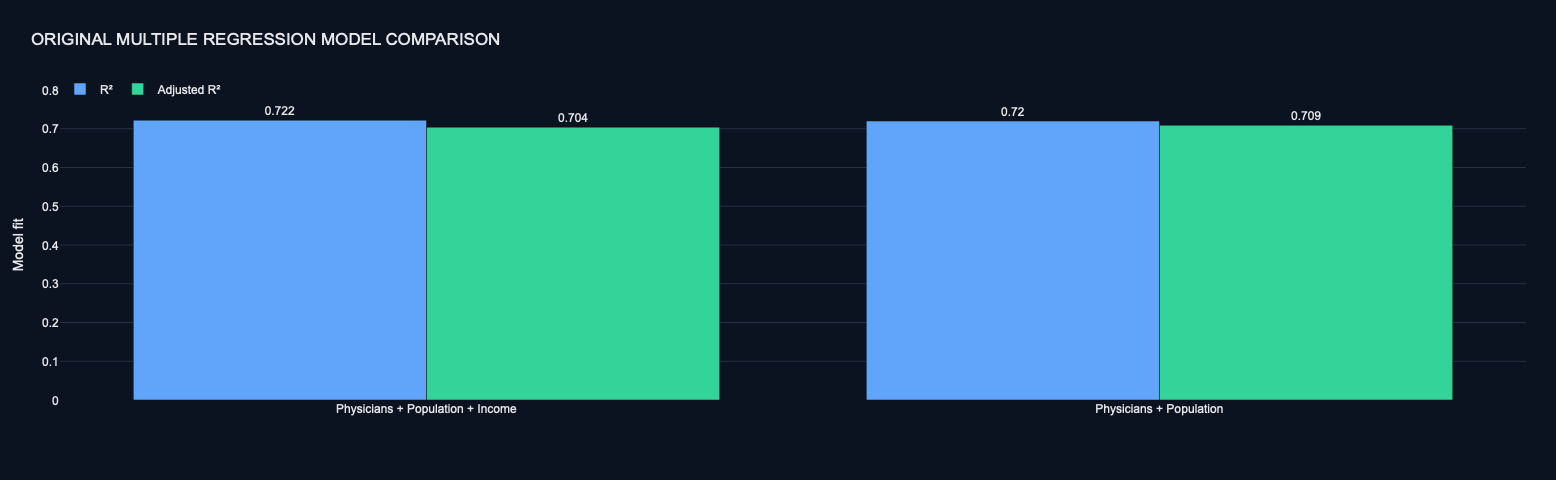

In [31]:
fig = go.Figure()

fig.add_trace(
    go.Bar(
        name="R²",
        x=multiple_regression_results["Model"],
        y=multiple_regression_results["R_squared"],
        marker_color="#60A5FA",
        text=multiple_regression_results["R_squared"].round(3),
        textposition="outside",
    )
)

fig.add_trace(
    go.Bar(
        name="Adjusted R²",
        x=multiple_regression_results["Model"],
        y=multiple_regression_results["Adjusted_R_squared"],
        marker_color="#34D399",
        text=multiple_regression_results["Adjusted_R_squared"].round(3),
        textposition="outside",
    )
)

fig.update_layout(
    title={
        "text": "ORIGINAL MULTIPLE REGRESSION MODEL COMPARISON",
        "x": 0.02,
        "xanchor": "left",
    },
    template="plotly_dark",
    paper_bgcolor="#0B1220",
    plot_bgcolor="#0B1220",
    height=480,
    barmode="group",
    margin=dict(l=60, r=30, t=90, b=80),
    font=dict(
        family="Arial",
        color="#E5E7EB",
    ),
    yaxis_title="Model fit",
    xaxis_title="",
    legend=dict(
        orientation="h",
        y=1.05,
        x=0,
    ),
)

fig.update_yaxes(
    range=[0, 0.8],
    gridcolor="#263244",
    zeroline=False,
)

fig.show()

In [32]:
reduced_model_coefficients = pd.DataFrame(
    {
        "Predictor": [
            "Physicians",
            "Population",
        ],
        "Coefficient": [
            4.7461,
            -0.0087,
        ],
        "p_value": [
            "<0.001",
            "<0.001",
        ],
    }
)

reduced_model_coefficients

,Predictor,Coefficient,p_value
0,Physicians,4.7461,<0.001
1,Population,-0.0087,<0.001


### Interpretation and limitations

The reduced two-variable model retained almost all of the explanatory power of
the three-variable model. In the original calculation, removing income changed
R² by only about 0.001.

Physician count remained positively associated with reported testing volume.
Population, however, changed from a positive association in its simple regression
to a negative coefficient when physician count was included in the multiple
model. That sign change is a reason to interpret the coefficients cautiously
rather than as independent causal effects.

Several additional limitations are important:

- the analysis contained only **51 state-level observations**;
- the variables are cross-sectional state totals rather than controlled
  experimental measurements;
- reported testing volumes were affected by rapidly changing testing capacity
  and reporting practices;
- several regression diagnostics showed strongly non-normal residuals;
- the multiple models reported very large condition numbers, indicating possible
  multicollinearity and/or numerical scaling problems;
- an association between a predictor and testing does not establish that the
  predictor caused higher or lower testing.

The regression therefore provides an exploratory view of relationships present
in the Spring 2020 state-level data rather than evidence of causal mechanisms.

## 05 · Financial-Market Analysis

The original project also explored how selected financial markets and companies
behaved during the opening months of the COVID-19 pandemic.

This portion of the analysis was developed by a teammate and examined:

- the NASDAQ Composite, S&P 500, and Dow Jones Industrial Average;
- Zoom, Delta Air Lines, and Expedia;
- monthly gold prices.

For the restored presentation, price series are shown relative to a common
starting value where appropriate. This makes differences in relative performance
easier to compare than the original raw-price charts.

> **Historical-data note:** The original Yahoo Finance files for Zoom, Delta Air
> Lines, and Expedia were recovered from the project archive. The complete
> 2019–2020 index files were not recovered; those three historical index series
> were reconstructed for the original date window and validated against values
> and observations preserved in the executed 2020 notebook. The stock-price
> source files are not redistributed in this repository.

### Major US market indices

The original project compared the NASDAQ Composite, S&P 500, and Dow Jones
Industrial Average from April 2019 through April 2020.

The restored visualization indexes each series to **100 on the first common
trading day**. A value of 90 therefore represents a level approximately 10%
below the starting value, while 110 represents approximately 10% above it.

![Relative performance of major US market indices](../assets/market_indices_indexed.png)

The three indices moved broadly together through much of the period and fell
sharply during the early-2020 market disruption. By late April, all three had
recovered part of the decline, although their relative recovery differed.

This is a descriptive comparison of market behavior during the pandemic period.
The price series alone do not establish that COVID-19 caused any particular
market movement.

### Selected companies

The original project also compared three companies with substantially different
business exposure during the early pandemic period: **Zoom**, **Delta Air Lines**,
and **Expedia**.

As with the market indices, the restored chart expresses each stock relative to
its value on the first common trading day.

![Relative performance of Zoom, Delta Air Lines, and Expedia](../assets/selected_companies_indexed.png)

The historical series show sharply different trajectories. Zoom appreciated
substantially relative to its starting level, while Delta Air Lines and Expedia
declined sharply during early 2020.

The original project related these patterns to increased reliance on
videoconferencing and disruption to travel. In the restored analysis, that
explanation is treated as contextual interpretation rather than evidence that
the pandemic alone caused the observed price movements.

### Gold prices

The original financial analysis also examined monthly gold prices to explore
whether their movement during early 2020 appeared distinctive relative to the
preceding year.

The historical gold-price dataset is included in this repository with documented
provenance, so this portion of the restored analysis remains directly
reproducible.

In [33]:
gold = pd.read_csv(
    RAW_DATA_DIR / "gold_monthly.csv"
)

gold["Date"] = pd.to_datetime(
    gold["Date"],
    format="%Y-%m",
)

gold_period = (
    gold[
        (gold["Date"] >= "2019-01-01")
        & (gold["Date"] <= "2020-03-31")
    ]
    .sort_values("Date")
    .copy()
)

gold_period

,Date,Price
828,2019-01-01,1291.630
829,2019-02-01,1319.755
830,2019-03-01,1302.286
831,2019-04-01,1287.650
832,2019-05-01,1282.460
833,2019-06-01,1358.488
834,2019-07-01,1414.611
835,2019-08-01,1497.102
836,2019-09-01,1510.336
837,2019-10-01,1494.765


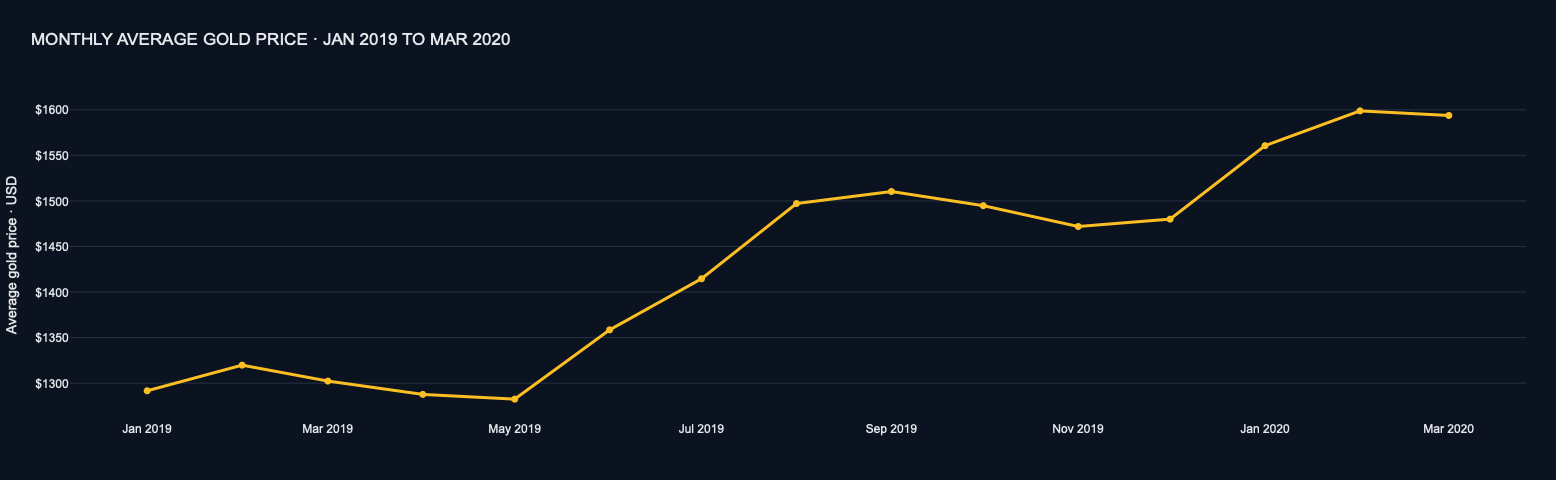

In [34]:
fig = go.Figure(
    go.Scatter(
        x=gold_period["Date"],
        y=gold_period["Price"],
        mode="lines+markers",
        line=dict(
            color="#FBBF24",
            width=3,
        ),
        marker=dict(size=7),
        hovertemplate=(
            "<b>%{x|%b %Y}</b><br>"
            "Average gold price: $%{y:,.2f}"
            "<extra></extra>"
        ),
    )
)

fig.update_layout(
    title={
        "text": "MONTHLY AVERAGE GOLD PRICE · JAN 2019 TO MAR 2020",
        "x": 0.02,
        "xanchor": "left",
    },
    template="plotly_dark",
    paper_bgcolor="#0B1220",
    plot_bgcolor="#0B1220",
    height=480,
    margin=dict(l=70, r=30, t=90, b=60),
    font=dict(
        family="Arial",
        color="#E5E7EB",
    ),
    xaxis_title="",
    yaxis_title="Average gold price · USD",
)

fig.update_xaxes(showgrid=False)

fig.update_yaxes(
    gridcolor="#263244",
    zeroline=False,
    tickprefix="$",
)

fig.show()

Gold prices were already trending upward during portions of 2019, with some
intermediate declines, and remained elevated into early 2020.

The limited monthly series does not demonstrate that the pandemic itself caused
the observed movement in gold prices. The restored analysis therefore retains
the original descriptive comparison without assigning a causal explanation.

## 06 · Limitations & Conclusion

### Limitations

This project was developed during the first months of the COVID-19 pandemic,
when both the disease and the available public datasets were changing rapidly.
The results should therefore be understood as a **historical analytical
snapshot**, not as a retrospective assessment using everything that became
known later.

Several limitations apply across the analysis:

- **Reported cases are not equivalent to true infections.** Testing availability,
  eligibility, reporting practices, and data completeness varied substantially
  across countries, US states, and time periods.

- **The observation windows differ slightly across datasets.** Most COVID-19
  analysis extends through approximately May 12–13, 2020, while the preserved
  US daily-case series ends on May 11 and the financial-market series generally
  extends through April 24, 2020.

- **Population-adjusted comparisons use 2018 population figures**, consistent
  with the data available to the original project.

- **Recent observations can be affected by reporting delays.** This is
  particularly important when interpreting the final days of the NYC daily
  case, hospitalization, and death series.

- **Cross-sectional regression identifies associations, not causal effects.**
  The state-level models use only 51 observations and show diagnostic concerns
  including non-normal residuals and large condition numbers.

- **Financial-market comparisons are descriptive.** Concurrent price movements
  cannot by themselves establish that the pandemic caused a particular market
  or company response.

- **Historical datasets evolved after the project was submitted.** The restored
  version therefore uses pinned or locally preserved snapshots where possible
  rather than silently substituting later revisions.

### Conclusion

This project explored the first wave of COVID-19 from several analytical
perspectives: global and US case patterns, the outbreak in New York City,
state-level testing relationships, and financial-market behavior.

The global analysis showed how rapidly the geographic concentration of reported
cases shifted during the opening months of the pandemic. Population-adjusted
comparisons also demonstrated why absolute case counts alone can provide an
incomplete view of cross-country burden.

Within the United States, reported cases were highly concentrated across a
relatively small number of states by mid-May 2020, while daily national case
counts illustrated both the rapid March increase and substantial day-to-day
reporting volatility.

New York City data provided a more detailed view of the first major urban
outbreak. Reported cases, hospitalizations, and deaths rose sharply before
declining within the historical observation window, while age-stratified data
showed especially large differences in severe-outcome rates across age groups.
The historical snapshot also showed higher reported hospitalization and death
rates for males than females.

The exploratory state-level regression suggested that physician count,
population, and income were associated with differences in reported testing
volume in the original data. Physician count showed the strongest individual
relationship, while the reduced multiple-regression model combining physicians
and population retained most of the explanatory power of the larger model.
These findings remain exploratory associations rather than evidence of causal
effects.

Finally, the financial analysis showed markedly different market trajectories
during early 2020. Major US indices experienced a sharp decline followed by a
partial recovery, while Zoom diverged substantially from Delta Air Lines and
Expedia. Gold prices were already following a broader upward trend before the
most acute pandemic period, illustrating why contemporaneous movement should
not automatically be attributed to COVID-19.

Taken together, the project demonstrates how multiple public datasets and
analytical approaches can be combined to examine a rapidly developing event.
The restored version preserves the questions, historical period, collaborative
analysis, and conclusions of the Spring 2020 project while improving
reproducibility, visual communication, code clarity, and the precision of the
interpretation.